Device: cuda
CSV path : /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Image dir: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder
Image files found: 16574
Classes: ['benign' 'malignant' 'non-neoplastic']
Loaded: light=1000, medium=1000, dark=2168
Dark benign available: 203
Loading CLIP ViT-L/14...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.
Loading images...
Extracting CLIP features (frozen)...
Features: light=(1000, 768), medium=(1000, 768), dark=(2168, 768)

Fixed test set: n=800
  Dark benign in test:     73 (0.091)
Reservoir: n=1368
  Reservoir benign:        130
  Reservoir non-benign:    1238

MAD RISK SCORE RECOVERY SWEEP
9 nc/Ng levels × 5 seeds = 45 runs, η=0.1

nc/Ng target=0.05  actual=0.0521  n_benign=11  n_dark_total=211
  MAD Risk Score: 0.0162  μ_cosine: 0.6885  Predicted: SAFE
  seed=42... benign_acc=0.342  auc=0.6517  min_wt=0.0000  collapse=True
  seed=0... benign_acc=0.521  auc=0.6222  min_wt=0.0000  collapse=True
  seed=1... benign_acc=0.000  auc=0.6035  min_wt=0.0000  collapse=True
  seed=7... benign_acc=0.000  auc=0.6615  min_wt=0.0000  collapse=True
  seed=99... benign_acc=0.000  auc=0.6370  min_wt=0.0000  collapse=True
  → Level summary: collapse_rate=100%  mean_benign_acc=0.173  CSV saved (5 rows)

nc/Ng target=0.10  actual=0.0991  n_benign=22  n_dark_total=222
  MAD Risk Score: 0.028

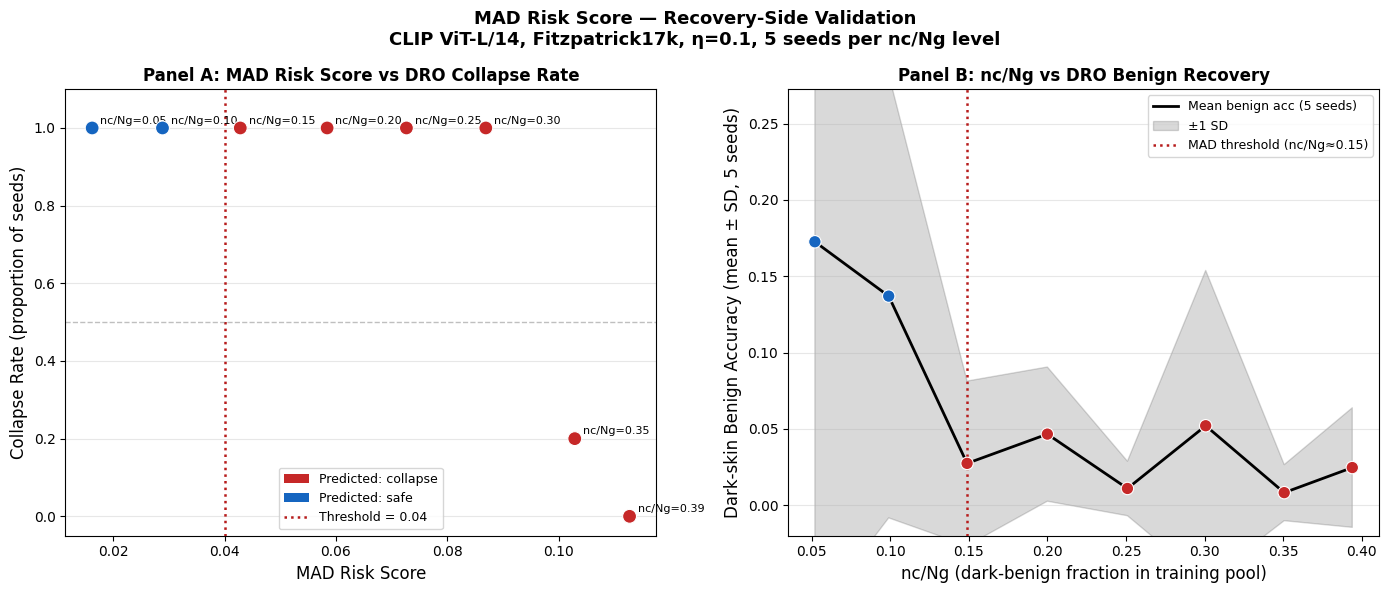

Figure saved: mad_recovery_curve.png

=== LaTeX TABLE ROWS ===
nc/Ng & MAD Risk & $\mu_{\cos}$ & Predicted & Collapse Rate & Benign Acc & Score Correct \\
\hline
0.052 & 0.0162 & 0.6885 & Safe & 5/5 & 0.173 $\pm$ 0.245 & \texttimes \\
0.099 & 0.0289 & 0.7087 & Safe & 5/5 & 0.137 $\pm$ 0.145 & \texttimes \\
0.149 & 0.0428 & 0.7124 & Collapse & 5/5 & 0.027 $\pm$ 0.054 & \checkmark \\
0.200 & 0.0584 & 0.7079 & Collapse & 5/5 & 0.047 $\pm$ 0.044 & \checkmark \\
0.251 & 0.0727 & 0.7104 & Collapse & 5/5 & 0.011 $\pm$ 0.018 & \checkmark \\
0.301 & 0.0869 & 0.7110 & Collapse & 5/5 & 0.052 $\pm$ 0.102 & \checkmark \\
0.351 & 0.1029 & 0.7066 & Collapse & 1/5 & 0.008 $\pm$ 0.018 & \checkmark \\
0.394 & 0.1127 & 0.7139 & Collapse & 0/5 & 0.025 $\pm$ 0.039 & \texttimes \\

=== INTERPRETATION FLAGS ===
MAD Risk Score prediction accuracy: 5/8 levels (62%)
  True positives  (predicted collapse, collapsed):  5
  True negatives  (predicted safe, did not collapse): 0
  False positives (predicted collapse

In [1]:
# ============================================================
# MAD Risk Score — Recovery-Side Validation
# CLIP ViT-L/14, Fitzpatrick17k, nc/Ng sweep
# GPU T4, Internet ON. ~90 min.
#
# WHY: The MAD Risk Score (MAD_risk = (nc/Ng) × (1 − μ_cosine))
# correctly flags all four architectures as being in the collapse
# regime. But it has only been validated on the *collapse* side
# (nc/Ng ≈ 9.4%): a binary classifier with zero negative examples
# in the test set is not a calibrated predictor. This notebook
# generates the *recovery* side by sweeping nc/Ng from 5% to 50%
# via controlled dark-benign upsampling, running Group DRO at each
# level with 5 seeds, and recording whether collapse occurs.
#
# PRIMARY QUESTION:
#   At what nc/Ng threshold does Group DRO transition from
#   systematic collapse (benign_acc ≈ 0%) to meaningful recovery?
#   Does the MAD Risk Score threshold (0.04) correctly separate
#   collapse from non-collapse across the full nc/Ng sweep?
#
# DESIGN:
#   Backbone: CLIP ViT-L/14 (FROZEN). Features extracted once,
#             cached across all sweep levels.
#   Classifier: nn.Linear(768→3), AdamW LR=1e-4, WD=1e-4.
#   DRO η: 0.1 (matches primary paper results, Tables 3–5).
#   Groups: skin_tone × label → 9 groups (3 skin × 3 classes).
#   Minority group tracked: dark-skin × benign (group 6).
#
#   nc/Ng SWEEP DESIGN:
#     Base pool: light (1000) + medium (1000) + dark non-benign
#                images from mitigation pool (fixed across levels).
#     Dark-benign images are drawn from a held-out reservoir
#     (separate from the fixed test set) and added incrementally.
#     nc/Ng at each level = n_dark_benign / n_dark_total_in_pool.
#     Target levels: {5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 50%}.
#     Actual nc/Ng may differ slightly from target depending on
#     available pool size — reported exactly in output.
#
#   Test set: FIXED across all nc/Ng levels (same dark images,
#             never in training pool). Identical to paper test set.
#
#   MAD Risk Score at each level:
#     Computed from frozen CLIP embeddings of dark-benign images
#     IN THE TRAINING POOL (not the test set — score must be
#     computable pre-intervention without test-set leakage).
#     μ_cosine = mean pairwise cosine similarity of dark-benign
#                embeddings in the current training pool.
#     MAD_risk = (nc/Ng) × (1 − μ_cosine).
#     Paper threshold: 0.04 → above = collapse predicted.
#
# SEEDS: {42, 0, 1, 7, 99} per nc/Ng level.
# DRO η: 0.1 (fixed; matches primary paper).
# Epochs: 5. Batch: 32. AdamW LR=1e-4, WD=1e-4.
#
# CSV SAVE: After every nc/Ng level completes (recoverable on
# timeout). File: mad_recovery_results.csv.
#
# OUTPUTS:
#   mad_recovery_results.csv         — one row per (nc_ng_level, seed)
#   mad_recovery_curve.png           — MAD Risk Score vs collapse prob
#   mad_recovery_score_vs_acc.png    — MAD Risk Score vs benign acc
#   (+ LaTeX table rows + plain summary printed at end)
#
# Kaggle: GPU T4 x1, Internet ON
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, os, json, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from itertools import combinations
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────
BASE_SEED      = 42
SEEDS          = [42, 0, 1, 7, 99]
# Target nc/Ng levels (actual may differ based on pool availability)
TARGET_NC_NG   = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
DRO_ETA        = 0.1          # matches Tables 3–5 in paper
N_EPOCHS       = 5
BATCH_SIZE     = 32
ADAMW_LR       = 1e-4
ADAMW_WD       = 1e-4
N_GROUPS       = 9            # 3 skin tones × 3 classes
FEAT_DIM       = 768
N_CLASSES      = 3
N_LIGHT        = 1000         # light images in base training pool
N_MEDIUM       = 1000         # medium images in base training pool
COLLAPSE_THR   = 0.01         # minority weight below this = collapse
MAD_THRESHOLD  = 0.04         # paper-reported collapse boundary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Dataset path auto-discovery ───────────────────────────────
_fitz_csv = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_root, _f)
            break
    if _fitz_csv:
        break

if _fitz_csv:
    fitz_csv     = _fitz_csv
    fitz_img_dir = os.path.dirname(_fitz_csv)
else:
    fitz_csv     = '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
    fitz_img_dir = '/kaggle/input/fitzpatrick17k/images'

print(f"CSV path : {fitz_csv}")
print(f"Image dir: {fitz_img_dir}")

# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv(fitz_csv)
df = df[df['fitzpatrick_scale'] > 0]
image_files = {}
for _img_root, _img_dirs, _img_files in os.walk(fitz_img_dir):
    for _img_f in _img_files:
        if _img_f.endswith('.jpg') or _img_f.endswith('.png'):
            _key = _img_f.replace('.jpg','').replace('.png','')
            image_files[_key] = os.path.join(_img_root, _img_f)
print(f"Image files found: {len(image_files)}")
df['local_path'] = df['md5hash'].map(image_files)
df = df[df['local_path'].notna()].copy()
df['skin_group'] = df['fitzpatrick_scale'].apply(
    lambda x: 'light' if x <= 2 else ('medium' if x <= 4 else 'dark'))

le = LabelEncoder()
le.fit(df['three_partition_label'].dropna().unique())
print(f"Classes: {le.classes_}")   # expect: benign, malignant, non-neoplastic

BENIGN_IDX = int(list(le.classes_).index('benign'))
MALIG_IDX  = int(list(le.classes_).index('malignant'))
NONNEO_IDX = int(list(le.classes_).index('non-neoplastic'))
MINORITY_G = 2 * N_CLASSES + BENIGN_IDX   # dark × benign = group 6

# ── Subset by skin group ──────────────────────────────────────
np.random.seed(BASE_SEED)
light_df  = df[df['skin_group']=='light'].sample(N_LIGHT,  random_state=BASE_SEED)
medium_df = df[df['skin_group']=='medium'].sample(N_MEDIUM, random_state=BASE_SEED)
dark_df   = df[df['skin_group']=='dark'].copy()
print(f"Loaded: light={len(light_df)}, medium={len(medium_df)}, dark={len(dark_df)}")
print(f"Dark benign available: {(dark_df['three_partition_label']=='benign').sum()}")

# ── Load CLIP ─────────────────────────────────────────────────
print("Loading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")

def load_imgs(dataframe):
    imgs, lbls, idxs = [], [], []
    for idx, row in dataframe.iterrows():
        try:
            img = Image.open(row['local_path']).convert('RGB').resize((224,224))
            imgs.append(img)
            lbls.append(le.transform([row['three_partition_label']])[0])
            idxs.append(idx)
        except:
            pass
    return imgs, np.array(lbls), idxs

@torch.no_grad()
def get_features(images, batch_size=32):
    all_feats = []
    for i in range(0, len(images), batch_size):
        batch  = images[i:i+batch_size]
        inputs = clip_proc(images=batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        feats  = clip_model.get_image_features(**inputs)
        if not isinstance(feats, torch.Tensor):
            feats = feats.pooler_output if hasattr(feats,'pooler_output') \
                    else feats.last_hidden_state[:,0]
        feats  = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().numpy())
    return np.vstack(all_feats)

# ── Extract features (once — reused across all sweep levels) ──
print("Loading images...")
light_imgs,  light_y,  _  = load_imgs(light_df)
medium_imgs, medium_y, _  = load_imgs(medium_df)
dark_imgs,   dark_y,   dark_idxs = load_imgs(dark_df)

print("Extracting CLIP features (frozen)...")
light_feats  = get_features(light_imgs)
medium_feats = get_features(medium_imgs)
dark_feats   = get_features(dark_imgs)
print(f"Features: light={light_feats.shape}, medium={medium_feats.shape}, "
      f"dark={dark_feats.shape}")

# ── Fixed test set ────────────────────────────────────────────
# Reserve the LAST 800 dark images (after shuffling) as fixed test set.
# The FIRST portion forms the reservoir from which we draw training
# images at each nc/Ng level. This ensures test set never leaks.
perm          = np.random.RandomState(BASE_SEED).permutation(len(dark_feats))
dark_feats_s  = dark_feats[perm]
dark_y_s      = dark_y[perm]

N_TEST        = 800   # fixed test set size
test_f        = dark_feats_s[-N_TEST:]
test_y        = dark_y_s[-N_TEST:]
reservoir_f   = dark_feats_s[:-N_TEST]   # available for training pools
reservoir_y   = dark_y_s[:-N_TEST]

# Within reservoir: separate benign from non-benign
res_benign_mask   = reservoir_y == BENIGN_IDX
res_nonbenign_mask = ~res_benign_mask

reservoir_benign_f    = reservoir_f[res_benign_mask]
reservoir_benign_y    = reservoir_y[res_benign_mask]
reservoir_nonbenign_f = reservoir_f[res_nonbenign_mask]
reservoir_nonbenign_y = reservoir_y[res_nonbenign_mask]

print(f"\nFixed test set: n={len(test_f)}")
print(f"  Dark benign in test:     {(test_y==BENIGN_IDX).sum()} "
      f"({(test_y==BENIGN_IDX).mean():.3f})")
print(f"Reservoir: n={len(reservoir_f)}")
print(f"  Reservoir benign:        {res_benign_mask.sum()}")
print(f"  Reservoir non-benign:    {res_nonbenign_mask.sum()}")

# Base non-dark pool (fixed across all levels)
light_skin_ids  = np.zeros(len(light_feats),  dtype=int)  # skin_id=0
medium_skin_ids = np.ones(len(medium_feats),   dtype=int)  # skin_id=1

# ── MAD Risk Score computation ────────────────────────────────
def compute_mad_risk(dark_benign_feats_in_pool, nc_ng):
    """
    MAD_risk = (nc/Ng) × (1 − μ_cosine)
    μ_cosine = mean pairwise cosine similarity of dark-benign
               embeddings IN THE TRAINING POOL (L2-normalized features
               → dot product = cosine similarity).
    Computed pre-intervention: no test-set access required.
    """
    if len(dark_benign_feats_in_pool) < 2:
        return float('nan'), float('nan')
    # Features already L2-normalized: dot product = cosine sim
    # Mean of all pairwise cosines (excluding self-similarity)
    n = len(dark_benign_feats_in_pool)
    if n > 500:
        # Sub-sample for efficiency if pool is very large
        rng = np.random.RandomState(BASE_SEED)
        idx = rng.choice(n, 500, replace=False)
        f   = dark_benign_feats_in_pool[idx]
    else:
        f = dark_benign_feats_in_pool
    sim_matrix = f @ f.T   # (n, n)
    mask = ~np.eye(len(f), dtype=bool)
    mu_cosine = sim_matrix[mask].mean()
    mad_risk  = nc_ng * (1.0 - mu_cosine)
    return float(mad_risk), float(mu_cosine)

# ── Helpers ───────────────────────────────────────────────────
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom  = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return max(0.0, center-margin), min(1.0, center+margin)

def eval_benign(preds, labels):
    mask = labels == BENIGN_IDX
    if mask.sum() == 0:
        return 0.0, 0.0, 0.0
    k  = int(accuracy_score(labels[mask], preds[mask]) * mask.sum())
    n  = int(mask.sum())
    lo, hi = wilson_ci(k, n)
    return k/n, lo, hi

# ── DRO training function ─────────────────────────────────────
def run_dro(base_feats, base_y, base_groups, eta_dro, seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

    head = nn.Linear(FEAT_DIM, N_CLASSES).to(device)
    nn.init.xavier_uniform_(head.weight)
    nn.init.zeros_(head.bias)
    optimizer = optim.AdamW(head.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    criterion = nn.CrossEntropyLoss(reduction='none')

    gen = torch.Generator()
    gen.manual_seed(seed)
    X_t = torch.tensor(base_feats,  dtype=torch.float32)
    Y_t = torch.tensor(base_y,      dtype=torch.long)
    G_t = torch.tensor(base_groups, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, Y_t, G_t),
                        batch_size=BATCH_SIZE, shuffle=True, generator=gen)

    q = torch.ones(N_GROUPS, device=device) / N_GROUPS
    epoch_minority_weights = []
    weight_collapse_by_ep2 = False

    for epoch in range(N_EPOCHS):
        head.train()
        for xb, yb, gb in loader:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            logits = head(xb)
            losses = criterion(logits, yb)

            total_loss = torch.zeros(1, device=device, requires_grad=True).squeeze()
            batch_group_losses = torch.zeros(N_GROUPS, device=device)
            for g in range(N_GROUPS):
                mask_g = (gb == g)
                if mask_g.sum() > 0:
                    gl = losses[mask_g].mean()
                    total_loss = total_loss + q[g].detach() * gl
                    batch_group_losses[g] = gl.detach()

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            with torch.no_grad():
                active = batch_group_losses > 0
                q[active] = q[active] * torch.exp(
                    torch.tensor(eta_dro, device=device) * batch_group_losses[active])
                q = q / q.sum()

        min_wt = float(q[MINORITY_G].item())
        epoch_minority_weights.append(min_wt)
        if epoch == 1:
            weight_collapse_by_ep2 = (min_wt < COLLAPSE_THR)

    head.eval()
    with torch.no_grad():
        test_t = torch.tensor(test_f, dtype=torch.float32).to(device)
        logits = head(test_t)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = np.argmax(probs, axis=1)

    benign_acc, ci_lo, ci_hi = eval_benign(preds, test_y)
    try:
        demo_auc = roc_auc_score(test_y, probs, multi_class='ovr', average='macro')
    except ValueError:
        demo_auc = float('nan')

    return {
        'benign_acc':             float(benign_acc),
        'benign_ci_lo':           float(ci_lo),
        'benign_ci_hi':           float(ci_hi),
        'demo_auc':               float(demo_auc),
        'final_minority_weight':  float(q[MINORITY_G].item()),
        'weight_collapse_by_ep2': bool(weight_collapse_by_ep2),
        'epoch_minority_weights': epoch_minority_weights,
    }

# ── Construct training pool for each nc/Ng level ──────────────
def build_pool_for_nc_ng(target_nc_ng, rng_state=BASE_SEED):
    """
    Build a dark-skin training pool with approximately target_nc_ng
    fraction of benign images.

    Strategy: fix n_dark_nonbenign = min(available, 200).
    Then solve for n_dark_benign such that:
      n_dark_benign / (n_dark_benign + n_dark_nonbenign) ≈ target_nc_ng
    i.e. n_dark_benign = round(target_nc_ng * n_dark_nonbenign
                               / (1 - target_nc_ng))
    Clip to available reservoir.
    """
    rng = np.random.RandomState(rng_state)

    n_nonbenign = min(200, len(reservoir_nonbenign_f))
    nb_idx = rng.choice(len(reservoir_nonbenign_f), n_nonbenign, replace=False)
    pool_nb_f = reservoir_nonbenign_f[nb_idx]
    pool_nb_y = reservoir_nonbenign_y[nb_idx]

    if target_nc_ng >= 1.0:
        n_benign = len(reservoir_benign_f)
    else:
        n_benign_target = round(target_nc_ng * n_nonbenign / (1.0 - target_nc_ng))
        n_benign = min(n_benign_target, len(reservoir_benign_f))
        n_benign = max(n_benign, 1)

    b_idx = rng.choice(len(reservoir_benign_f), n_benign, replace=False)
    pool_b_f = reservoir_benign_f[b_idx]
    pool_b_y = reservoir_benign_y[b_idx]

    dark_pool_f    = np.vstack([pool_nb_f, pool_b_f])
    dark_pool_y    = np.concatenate([pool_nb_y, pool_b_y])
    dark_skin_ids  = np.full(len(dark_pool_f), 2, dtype=int)  # skin_id=2

    actual_nc_ng = n_benign / len(dark_pool_f)

    # Full training set
    base_f      = np.vstack([light_feats, medium_feats, dark_pool_f])
    base_y      = np.concatenate([light_y, medium_y, dark_pool_y])
    base_skin   = np.concatenate([light_skin_ids, medium_skin_ids, dark_skin_ids])
    base_groups = (base_skin * N_CLASSES + base_y).astype(int)

    return base_f, base_y, base_groups, actual_nc_ng, pool_b_f, n_benign, len(dark_pool_f)

# ── Main sweep loop ───────────────────────────────────────────
all_rows  = []
csv_path  = '/kaggle/working/mad_recovery_results.csv'

print("\n" + "="*70)
print(f"MAD RISK SCORE RECOVERY SWEEP")
print(f"{len(TARGET_NC_NG)} nc/Ng levels × {len(SEEDS)} seeds = "
      f"{len(TARGET_NC_NG)*len(SEEDS)} runs, η={DRO_ETA}")
print("="*70)

for target_ncng in TARGET_NC_NG:
    (base_f, base_y, base_groups,
     actual_ncng, benign_pool_f,
     n_benign, n_dark_total) = build_pool_for_nc_ng(target_ncng)

    # Compute MAD Risk Score from training pool features
    mad_risk, mu_cosine = compute_mad_risk(benign_pool_f, actual_ncng)
    predicted_collapse  = mad_risk > MAD_THRESHOLD

    print(f"\nnc/Ng target={target_ncng:.2f}  actual={actual_ncng:.4f}  "
          f"n_benign={n_benign}  n_dark_total={n_dark_total}")
    print(f"  MAD Risk Score: {mad_risk:.4f}  "
          f"μ_cosine: {mu_cosine:.4f}  "
          f"Predicted: {'COLLAPSE' if predicted_collapse else 'SAFE'}")

    level_rows = []
    for seed in SEEDS:
        print(f"  seed={seed}...", end=' ', flush=True)
        res = run_dro(base_f, base_y, base_groups, DRO_ETA, seed)
        row = {
            'target_nc_ng':           target_ncng,
            'actual_nc_ng':           actual_ncng,
            'n_benign_in_pool':       n_benign,
            'n_dark_total_in_pool':   n_dark_total,
            'mad_risk':               mad_risk,
            'mu_cosine':              mu_cosine,
            'predicted_collapse':     predicted_collapse,
            'seed':                   seed,
            'benign_acc':             res['benign_acc'],
            'benign_ci_lo':           res['benign_ci_lo'],
            'benign_ci_hi':           res['benign_ci_hi'],
            'demo_auc':               res['demo_auc'],
            'final_minority_weight':  res['final_minority_weight'],
            'weight_collapse_by_ep2': res['weight_collapse_by_ep2'],
        }
        print(f"benign_acc={res['benign_acc']:.3f}  "
              f"auc={res['demo_auc']:.4f}  "
              f"min_wt={res['final_minority_weight']:.4f}  "
              f"collapse={res['weight_collapse_by_ep2']}")
        level_rows.append(row)
        all_rows.append(row)

    # Save after every level (recoverable)
    pd.DataFrame(all_rows).to_csv(csv_path, index=False)
    collapse_rate = np.mean([r['weight_collapse_by_ep2'] for r in level_rows])
    mean_acc      = np.mean([r['benign_acc'] for r in level_rows])
    print(f"  → Level summary: collapse_rate={collapse_rate:.0%}  "
          f"mean_benign_acc={mean_acc:.3f}  CSV saved ({len(all_rows)} rows)")

# ── Aggregate results ─────────────────────────────────────────
df_res = pd.DataFrame(all_rows)

agg = df_res.groupby('actual_nc_ng').agg(
    mad_risk           = ('mad_risk',               'first'),
    mu_cosine          = ('mu_cosine',              'first'),
    predicted_collapse = ('predicted_collapse',     'first'),
    n_benign           = ('n_benign_in_pool',       'first'),
    n_dark_total       = ('n_dark_total_in_pool',   'first'),
    benign_acc_mean    = ('benign_acc',             'mean'),
    benign_acc_std     = ('benign_acc',             'std'),
    collapse_rate      = ('weight_collapse_by_ep2', 'mean'),
    min_wt_mean        = ('final_minority_weight',  'mean'),
).reset_index()

# Observed collapse = any seed collapsed
agg['any_collapse'] = agg['collapse_rate'] > 0

# Score correctness: predicted_collapse matches observed collapse
agg['score_correct'] = agg['predicted_collapse'] == agg['any_collapse']

print("\n=== SUMMARY TABLE ===")
print(f"{'nc/Ng':>8} {'MAD_risk':>10} {'μ_cos':>8} {'Pred':>10} "
      f"{'Collapse%':>12} {'Benign Acc':>14} {'Correct?':>10}")
print("-"*78)
for _, row in agg.iterrows():
    pred_str = 'COLLAPSE' if row['predicted_collapse'] else 'SAFE    '
    corr_str = '✓' if row['score_correct'] else '✗'
    print(f"{row['actual_nc_ng']:>8.4f} {row['mad_risk']:>10.4f} "
          f"{row['mu_cosine']:>8.4f} {pred_str:>10} "
          f"{row['collapse_rate']:>11.0%}  "
          f"{row['benign_acc_mean']:>6.3f} ± {row['benign_acc_std']:.3f}  "
          f"{corr_str:>10}")

accuracy_score_val = agg['score_correct'].mean()
print(f"\nMAD Risk Score prediction accuracy: "
      f"{accuracy_score_val:.0%} ({agg['score_correct'].sum()}/{len(agg)} levels)")

# ── Figure 1: Recovery curve (MAD Risk Score vs collapse prob) ─
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'MAD Risk Score — Recovery-Side Validation\n'
    'CLIP ViT-L/14, Fitzpatrick17k, η=0.1, 5 seeds per nc/Ng level',
    fontsize=13, fontweight='bold'
)

# Panel A: MAD Risk Score vs Collapse Rate
ax = axes[0]
colors = ['#C62828' if pred else '#1565C0'
          for pred in agg['predicted_collapse']]
sc = ax.scatter(agg['mad_risk'], agg['collapse_rate'],
                c=colors, s=100, zorder=5, edgecolors='white', linewidths=0.8)
for _, row in agg.iterrows():
    ax.annotate(f"nc/Ng={row['actual_nc_ng']:.2f}",
                (row['mad_risk'], row['collapse_rate']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.axvline(MAD_THRESHOLD, color='#B71C1C', linestyle=':', linewidth=1.8,
           label=f'Threshold = {MAD_THRESHOLD}')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.0, alpha=0.5,
           label='50% collapse rate')
ax.set_xlabel('MAD Risk Score', fontsize=12)
ax.set_ylabel('Collapse Rate (proportion of seeds)', fontsize=12)
ax.set_title('Panel A: MAD Risk Score vs DRO Collapse Rate', fontweight='bold')
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#C62828', label='Predicted: collapse'),
    Patch(facecolor='#1565C0', label='Predicted: safe'),
    plt.Line2D([0],[0], color='#B71C1C', linestyle=':', linewidth=1.8,
               label=f'Threshold = {MAD_THRESHOLD}'),
]
ax.legend(handles=legend_els, fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Panel B: nc/Ng vs Mean Benign Accuracy with error bands
ax = axes[1]
nc_ng_vals = agg['actual_nc_ng'].values
acc_mean   = agg['benign_acc_mean'].values
acc_std    = agg['benign_acc_std'].values
colors_b   = ['#C62828' if pred else '#1565C0'
               for pred in agg['predicted_collapse']]
ax.plot(nc_ng_vals, acc_mean, color='black', linewidth=2.0,
        linestyle='-', zorder=3, label='Mean benign acc (5 seeds)')
ax.fill_between(nc_ng_vals, acc_mean - acc_std, acc_mean + acc_std,
                alpha=0.15, color='black', label='±1 SD')
ax.scatter(nc_ng_vals, acc_mean, c=colors_b, s=80,
           zorder=5, edgecolors='white', linewidths=0.8)
# Mark threshold
# Find nc/Ng corresponding to MAD_risk ≈ threshold
threshold_ncng = agg.loc[
    (agg['mad_risk'] - MAD_THRESHOLD).abs().idxmin(), 'actual_nc_ng']
ax.axvline(threshold_ncng, color='#B71C1C', linestyle=':',
           linewidth=1.8, label=f'MAD threshold (nc/Ng≈{threshold_ncng:.2f})')
ax.set_xlabel('nc/Ng (dark-benign fraction in training pool)', fontsize=12)
ax.set_ylabel('Dark-skin Benign Accuracy (mean ± SD, 5 seeds)', fontsize=12)
ax.set_title('Panel B: nc/Ng vs DRO Benign Recovery', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-0.02, max(acc_mean) + 0.10)

plt.tight_layout()
plt.savefig('/kaggle/working/mad_recovery_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: mad_recovery_curve.png")

# ── LaTeX table rows ──────────────────────────────────────────
print("\n=== LaTeX TABLE ROWS ===")
print("nc/Ng & MAD Risk & $\\mu_{\\cos}$ & Predicted & Collapse Rate & "
      "Benign Acc & Score Correct \\\\")
print("\\hline")
for _, row in agg.iterrows():
    pred_str = 'Collapse' if row['predicted_collapse'] else 'Safe'
    corr_str = '\\checkmark' if row['score_correct'] else '\\texttimes'
    n_col = int(row['collapse_rate'] * len(SEEDS))
    print(f"{row['actual_nc_ng']:.3f} & {row['mad_risk']:.4f} & "
          f"{row['mu_cosine']:.4f} & {pred_str} & "
          f"{n_col}/{len(SEEDS)} & "
          f"{row['benign_acc_mean']:.3f} $\\pm$ {row['benign_acc_std']:.3f} & "
          f"{corr_str} \\\\")

# ── Interpretation flags ──────────────────────────────────────
print("\n=== INTERPRETATION FLAGS ===")
n_correct   = agg['score_correct'].sum()
n_total     = len(agg)
tp = int(((agg['predicted_collapse']) & (agg['any_collapse'])).sum())
tn = int(((~agg['predicted_collapse']) & (~agg['any_collapse'])).sum())
fp = int(((agg['predicted_collapse']) & (~agg['any_collapse'])).sum())
fn = int(((~agg['predicted_collapse']) & (agg['any_collapse'])).sum())
print(f"MAD Risk Score prediction accuracy: {n_correct}/{n_total} levels "
      f"({n_correct/n_total:.0%})")
print(f"  True positives  (predicted collapse, collapsed):  {tp}")
print(f"  True negatives  (predicted safe, did not collapse): {tn}")
print(f"  False positives (predicted collapse, did not):    {fp}")
print(f"  False negatives (predicted safe, collapsed):      {fn}")

# Threshold boundary
collapse_levels  = agg[agg['any_collapse']]['actual_nc_ng']
recovery_levels  = agg[~agg['any_collapse']]['actual_nc_ng']
if len(recovery_levels) > 0:
    print(f"\nObserved collapse at nc/Ng ≤ {collapse_levels.max():.4f}")
    print(f"Observed recovery at nc/Ng ≥ {recovery_levels.min():.4f}")
else:
    print("\nNo recovery observed — DRO collapsed at all tested nc/Ng levels.")
    print("IMPLICATION: Fitzpatrick17k dark pool may be too small to reach "
          "recovery threshold. Recommend extending to full Fitzpatrick pool "
          "or external dataset.")

print(f"\nMAD threshold used: {MAD_THRESHOLD}")
boundary_row = agg.loc[(agg['mad_risk'] - MAD_THRESHOLD).abs().idxmin()]
print(f"Closest nc/Ng to threshold: {boundary_row['actual_nc_ng']:.4f} "
      f"(MAD_risk={boundary_row['mad_risk']:.4f})")

print("\n=== FULL PER-RUN TABLE ===")
print(f"{'nc/Ng':>8} {'seed':>6} {'mad_risk':>10} {'benign_acc':>12} "
      f"{'demo_auc':>10} {'min_wt':>10} {'collapse':>10}")
for _, row in df_res.iterrows():
    print(f"{row['actual_nc_ng']:>8.4f} {row['seed']:>6} "
          f"{row['mad_risk']:>10.4f} {row['benign_acc']:>12.3f} "
          f"{row['demo_auc']:>10.4f} {row['final_minority_weight']:>10.4f} "
          f"{str(row['weight_collapse_by_ep2']):>10}")

print(f"\n✓ Complete.")
print(f"Files: mad_recovery_curve.png, mad_recovery_results.csv")
print(f"Upload figure + paste ALL output (especially LaTeX rows and "
      f"interpretation flags) to Claude.")
